In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Dataset load karein
df = pd.read_csv('superstore.csv', encoding='latin1')

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
df.head()

Dataset Shape: (9994, 21)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
# Blank customer IDs remove karein
df_clean = df.dropna(subset=['Customer ID']).copy()

# Column names confirm aur clean karein
order_date_col = 'Order Date' if 'Order Date' in df_clean.columns else 'Order_Date'
sales_col = 'Sales' if 'Sales' in df_clean.columns else 'TotalAmount'
order_id_col = 'Order ID' if 'Order ID' in df_clean.columns else 'Order_ID'
cust_id_col = 'Customer ID' if 'Customer ID' in df_clean.columns else 'Customer_ID'

# Date format fix karein
df_clean[order_date_col] = pd.to_datetime(df_clean[order_date_col], dayfirst=True, errors='coerce')

# Snapshot Date (Recency calculate karne ke liye)
snapshot_date = df_clean[order_date_col].max() + pd.Timedelta(days=1)

# RFM Metrics Aggregation
rfm = df_clean.groupby(cust_id_col).agg({
    order_date_col: lambda x: (snapshot_date - x.max()).days, # Recency
    order_id_col: 'nunique',                                  # Frequency
    sales_col: 'sum'                                          # Monetary
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']
print("RFM Summary:")
rfm.head()

RFM Summary:


,Customer_ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [9]:
# Log transform (skewness fix karne ke liye)
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# StandardScaler fit karein
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,0.728418,-0.344103,1.013567
1,-1.003115,0.994033,-0.568377
2,0.997348,-0.821704,-0.066099
3,-0.210448,0.059703,0.928264
4,1.369312,-1.406241,-0.735599


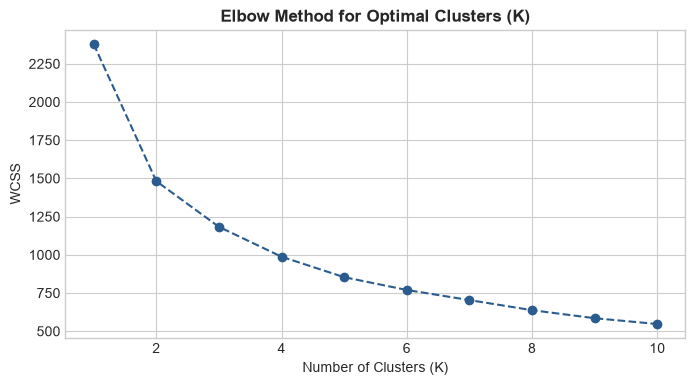

In [10]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='#2b5c8f')
plt.title('Elbow Method for Optimal Clusters (K)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# Optimal K = 4 Apply karein
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

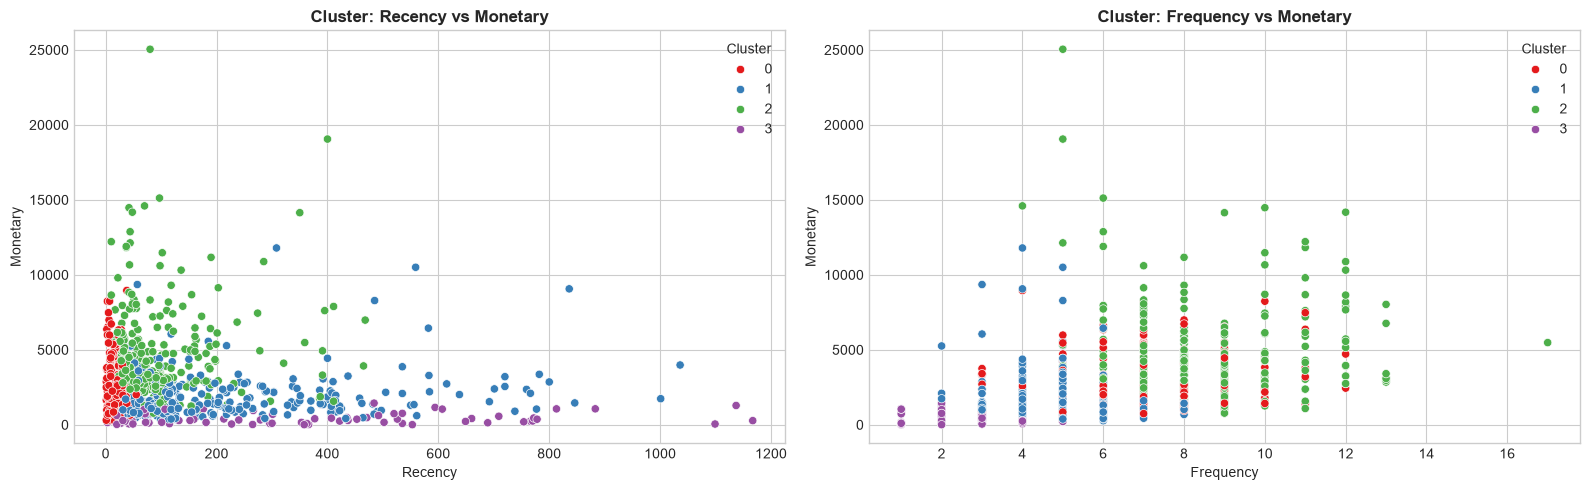

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Recency vs Monetary
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[0])
axes[0].set_title('Cluster: Recency vs Monetary', fontsize=12, fontweight='bold')

# Plot 2: Frequency vs Monetary
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', ax=axes[1])
axes[1].set_title('Cluster: Frequency vs Monetary', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

   Cluster         Segment_Name  Customer_Count     Recency  Frequency  \
0        0   At-Risk / Inactive             199   19.723618   6.783920   
1        1      Loyal Champions             253  235.221344   4.857708   
2        2  New / Recent Buyers             258  103.333333   8.589147   
3        3   Big Spenders (VIP)              83  326.674699   2.578313   

      Monetary  
0  2712.878566  
1  1936.831874  
2  4773.039956  
3   432.231961  


C:\Users\hk516\AppData\Local\Temp\ipykernel_1252\942828994.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary, x='Segment_Name', y='Customer_Count', palette='viridis')


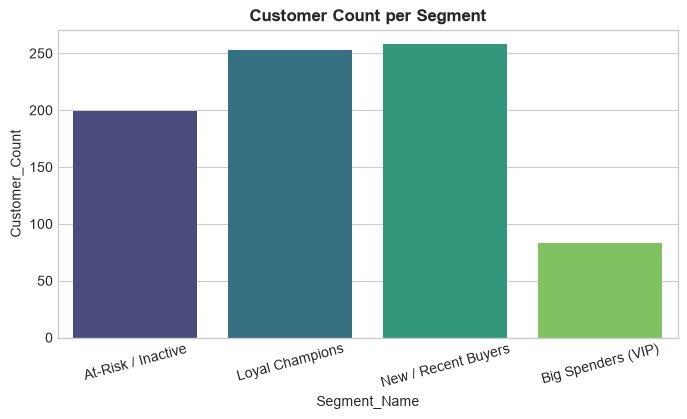

In [12]:
# Cluster Average Values
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer_ID': 'count'
}).rename(columns={'Customer_ID': 'Customer_Count'}).reset_index()

# Human Readable Names Assign Karein
segment_names = {
    0: 'At-Risk / Inactive',
    1: 'Loyal Champions',
    2: 'New / Recent Buyers',
    3: 'Big Spenders (VIP)'
}
cluster_summary['Segment_Name'] = cluster_summary['Cluster'].map(segment_names)
rfm['Segment_Name'] = rfm['Cluster'].map(segment_names)

print(cluster_summary[['Cluster', 'Segment_Name', 'Customer_Count', 'Recency', 'Frequency', 'Monetary']])

# Customer Count Bar Chart
plt.figure(figsize=(8, 4))
sns.barplot(data=cluster_summary, x='Segment_Name', y='Customer_Count', palette='viridis')
plt.title('Customer Count per Segment', fontsize=12, fontweight='bold')
plt.xticks(rotation=15)
plt.show()

## Business Recommendations by Customer Segment

1. **Big Spenders (VIP):** Exclusive VIP loyalty programs launch karein, early product access dein, aur special support services dein.
2. **Loyal Champions:** Cross-sell strategies apply karein aur subscription/repeat discounts dein taake inki frequency barkarar rahe.
3. **New / Recent Buyers:** Automated welcome emails, first-repeat discounts, aur feedback surveys ke zariye retarget karein.
4. **At-Risk / Inactive:** Win-back email campaigns aur limited-time high discount offers ke zariye re-engage karein.